In [462]:
import numpy as np
import torch 
import matplotlib.pyplot as plt

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc
import utils.data
from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from models.trainer_ESN_MMD import train_ESN_MMD
from sigkernel_.loss import compute_mmd_loss
from utils.analyse_training import plot_loss_from_run, inspect_run_and_mmd, acf_analysis, plot_W_history_vs_fixed, plot_terminal_histograms
from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generator and ESN

In [463]:
T = 50 # length of time series
N = 100  # number of samples
batch_size = N
N_target = N
target_rho = 0.99
xi_ma_theta = None # based on the ACF at the end
d = 1   # dimension of time series

# Shared by both ESN
h, m, d = 3, 1, 1 # ESN hyperparameters: reservoir size, input dimension (\xi : randomness), output dimension
activation = "tanh"
quad_feedback = False # whether to include quadratic feedback in the ESN reservoir (to capture some nonlinearity and volatility clustering)
quad_gain = 0.0 # if set to 0.0 then no quadratic feedback
xi_scale = 1.0
eta_scale = 0.00

# ESN estimator
A = 0.9 * torch.randn(h, h) / (h ** 0.5) # ESN reservoir weight matrix
C = torch.randn(h, m) / (m ** 0.5) # ESN input weight matrix

esn = ESNGenerator(A, C, out_dim=d, xi_scale=xi_scale, eta_scale=eta_scale, activation=activation, target_rho=target_rho, xi_ma_theta=xi_ma_theta, quad_feedback=quad_feedback, quad_gain=quad_gain)
norm_W = torch.linalg.norm(esn.W)

# ESN target
A_target = A.clone()
C_target = C.clone()
_W_fixed = torch.randn(d, h) # important
W_fixed = _W_fixed * (norm_W / torch.linalg.norm(_W_fixed))
target_esn = ESNGenerator(A_target, C_target, out_dim=d, xi_scale=xi_scale, eta_scale=eta_scale, activation=activation, target_rho=target_rho, xi_ma_theta=xi_ma_theta, quad_feedback=quad_feedback, quad_gain=quad_gain)
with torch.no_grad():
    target_esn.W.copy_(W_fixed.to(dtype=target_esn.W.dtype, device=target_esn.W.device))
target_esn.W.requires_grad_(False)

target_generator = ESNAsTarget(target_esn, T_default=T)
norm_W_target = torch.linalg.norm(target_esn.W)

print(f"Norm of ESN reservoir weights: {norm_W:.4f}")
print(f"Norm of target ESN reservoir weights: {norm_W_target:.4f}")


Norm of ESN reservoir weights: 0.2440
Norm of target ESN reservoir weights: 0.2440


# Kernels

In [464]:
noise = Noise("normal")
with torch.no_grad():
    X = target_generator.generate(N=N, noise=noise).to(device=device, dtype=dtype)
    Z = esn(T=T, N=N).to(device=device, dtype=dtype)
print(f"Generated data shapes: X: {X.shape}, Z: {Z.shape}")
_median_heuristic_sigma = median_heuristic_sigma(X,Z)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Generated data shapes: X: torch.Size([100, 50, 1]), Z: torch.Size([100, 50, 1])
Median heuristic sigma: 0.392526


In [465]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
# disc_sig_kernel_sigma = 1e-3 # bandwidth parameter for the static kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

kwargs_disc_sig = {
    'static_kernel_type': static_kernel_type,
    'n_levels': n_levels,
    'kernel_sigma': disc_sig_kernel_sigma,
}

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**kwargs_disc_sig)

#---------------------------------
# Define the pde signature kernel
# pde_sig_sigma = 1e1 # bandwidth parameter for the static kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

# Initialize the corresponding signature kernel
sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# # Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

### Choose which kernel

In [466]:
# choose one:
# kernel = sig_disc_kernel      # discretized signature kernel
# kernel = sig_pde_kernel        # pde signature kernel
kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel      # volterra kernel

if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
# initial mmd:
initial_mmd = compute_mmd_loss(kernel, X, Z) if kernel_mode == "sequential" else compute_mmd_loss(kernel, X.reshape(X.shape[0], -1), Z.reshape(Z.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

mmd_sig_disc = compute_mmd_loss(sig_disc_kernel, X, Z)
mmd_rbf = compute_mmd_loss(rbf_kernel, X.reshape(X.shape[0], -1), Z.reshape(Z.shape[0], -1))
mmd_sig_pde = compute_mmd_loss(sig_pde_kernel, X, Z)
print(f"Initial MMD (sig disc kernel): {mmd_sig_disc:.6f}")
print(f"Initial MMD (RBF kernel): {mmd_rbf:.6f}")
print(f"Initial MMD (sig pde kernel): {mmd_sig_pde:.6f}")

Using kernel: RBFKernel with kernel mode: static
Initial MMD with RBFKernel kernel: 0.052570
Initial MMD (sig disc kernel): 0.379148
Initial MMD (RBF kernel): 0.052570
Initial MMD (sig pde kernel): 0.000069


# Define parameters

In [467]:
train_params = {
    "epochs": 1000,
    "batch_size": N,
    "T": T,
    "d": d,
    "target_rho": target_rho,
    "esn": esn,
    "target_generator": target_generator,
    "noise": noise,
    "kernel": kernel,
    "kernel_mode": kernel_mode,
}

if "dataloader" in locals() and dataloader is not None:
    run_name = f"esn_vs_{dataloader.__class__.__name__}_{kernel.__class__.__name__}"
elif "target_generator" in locals() and target_generator is not None:
    run_name = f"esn_vs_{target_generator.__class__.__name__}_{kernel.__class__.__name__}"
else:
    raise ValueError("Neither dataloader nor target_generator is defined.")

optim_params = {
    "lr": 1e-3,
    "lr_factor": 0.5,
    "plateau_patience": 75,
    "max_lr_drops": 3,
    "early_stopping_patience": 250,
    "min_lr": 1e-6,
}

loss_params = {
    "lead_lag": False,
    "lags": 1,
    "num_losses": 20,
}

io_params = {
    "out_dir": "./runs",
    "run_name": run_name,
    "save_every": 50,
}

misc_params = {
    "dtype": torch.float64,
    "device": device,
}

kwargs = {
    **train_params,
    **optim_params,
    **loss_params,
    **io_params,
    **misc_params,
}

### Observe the generated paths before training

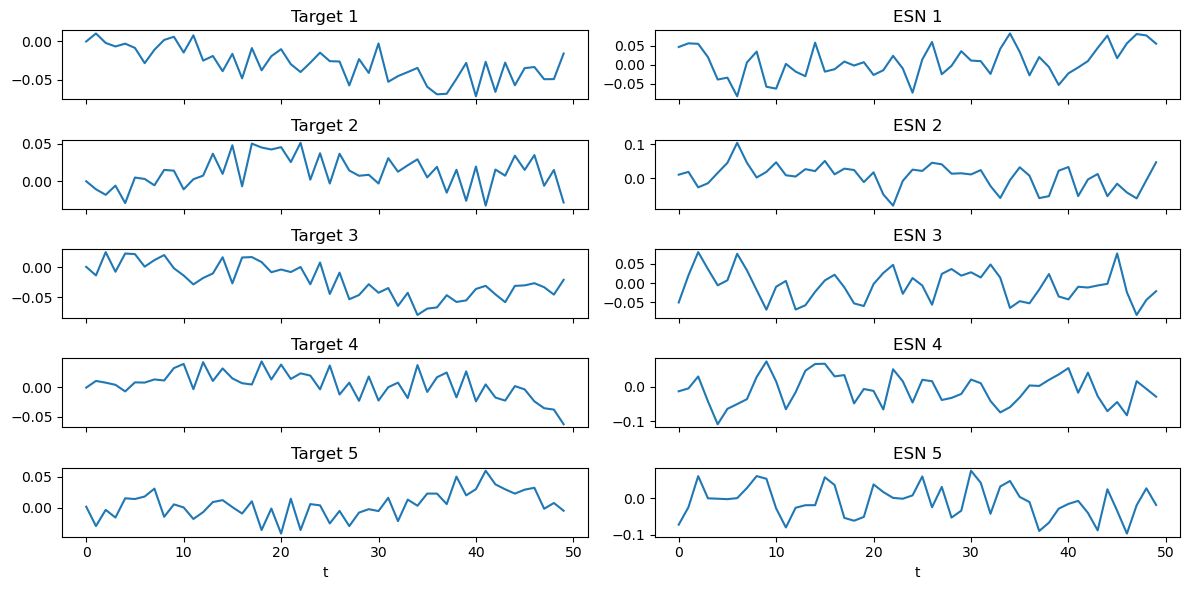

MMD: 0.046281026231027145


In [468]:
inspection = inspect_run_and_mmd(results=None, kwargs=kwargs, n_examples=5, kernel_mmd = None)   

# Training

In [469]:
results = train_ESN_MMD(**kwargs)

Noise(kind='normal', params=None)


train:  48%|████▊     | 476/1000 [00:04<00:04, 123.55it/s, avg_k=-.000865, drops=1, loss=-.00365, lr=0.0005] 

LR drop 1/3: lr -> 0.0005


train:  55%|█████▌    | 554/1000 [00:04<00:03, 112.41it/s, avg_k=-.00139, drops=2, loss=-.00254, lr=0.00025]  

LR drop 2/3: lr -> 0.00025


train:  71%|███████   | 709/1000 [00:06<00:02, 116.90it/s, avg_k=0.000842, drops=3, loss=-.00129, lr=0.000125] 

LR drop 3/3: lr -> 0.000125


train:  87%|████████▋ | 870/1000 [00:07<00:01, 114.46it/s, avg_k=0.000617, drops=3, loss=0.00726, lr=0.000125] 


Early stopping at epoch 870 (best avg_20 -0.0030831 at epoch 620, lr_drops_used=3)


# Visualize and analyse results

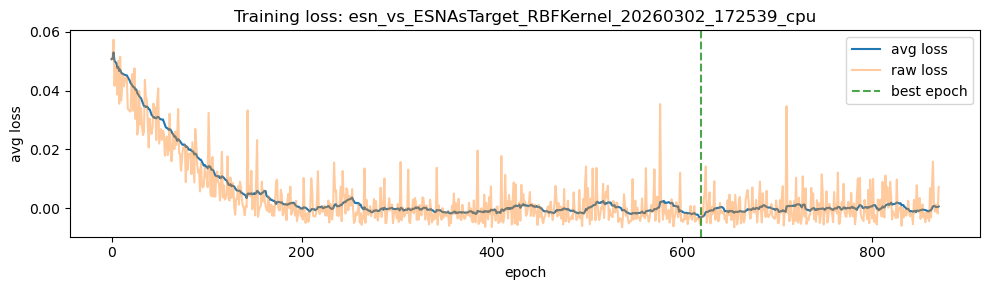

Final average loss: 0.0006
Final loss: 0.0073
Best average loss: -0.0031 at epoch 620


In [470]:
losses = plot_loss_from_run(results, kwargs, overlay_raw=True, log_scale=False, overlay_lr = True, mark_best_and_drops=True)
print(f"Final average loss: {losses['avg_losses'][-1]:.4f}")
print(f"Final loss: {losses['losses'][-1]:.4f}")
print(f"Best average loss: {losses['best_avg_loss']:.4f} at epoch {losses['best_epoch']}")


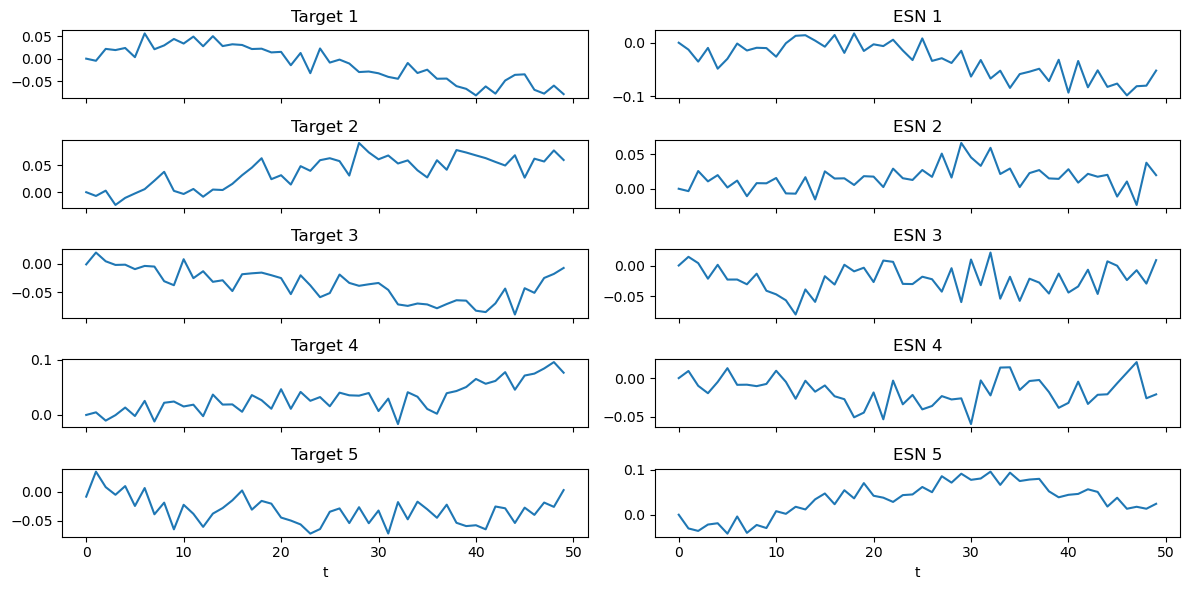

MMD: -0.001438515468397461


In [471]:
inspection = inspect_run_and_mmd(results, kwargs, n_examples=5, kernel_mmd = rbf_kernel, use_best=True)   

# ACF analysis

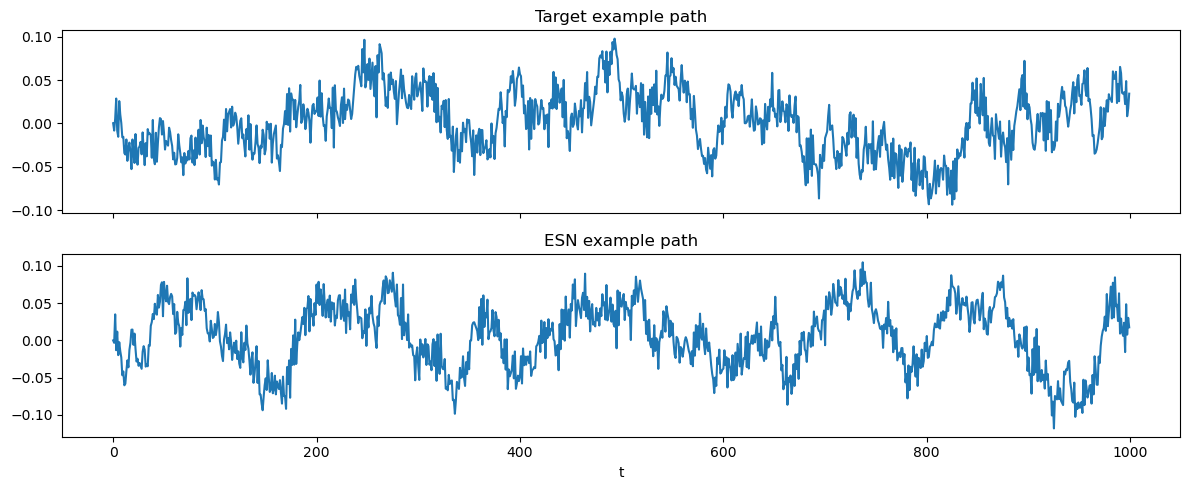

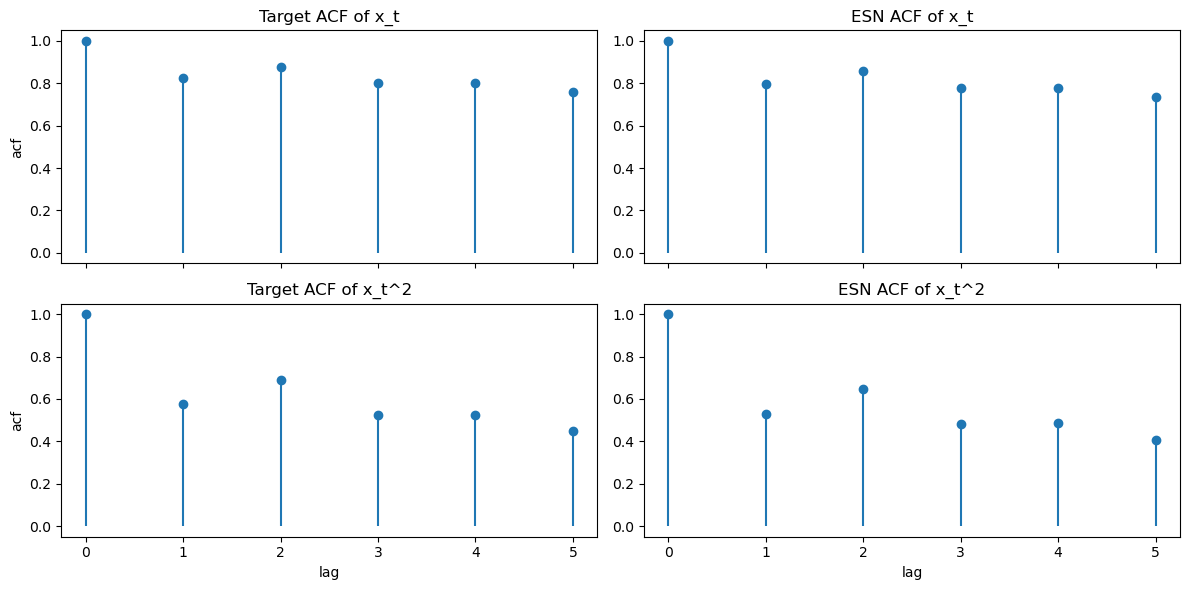

In [472]:
out = acf_analysis(results, kwargs, T_acf=1000, N_paths=100, lag_acf=5)

# Distribution at time T

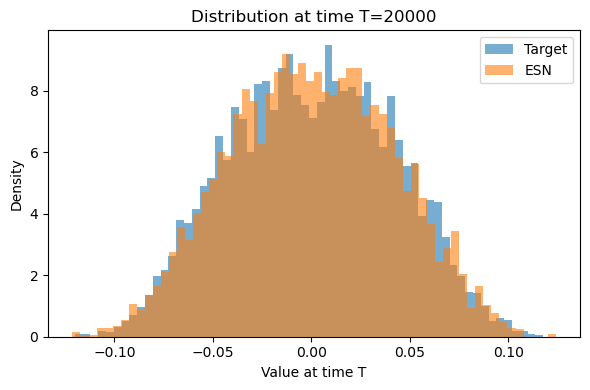

In [479]:
plot_terminal_histograms(
    target_generator=target_generator,
    esn=esn,
    N=5000,
    T=1000,
    bins=60,
)

# Compare W_fixed vs W_learned

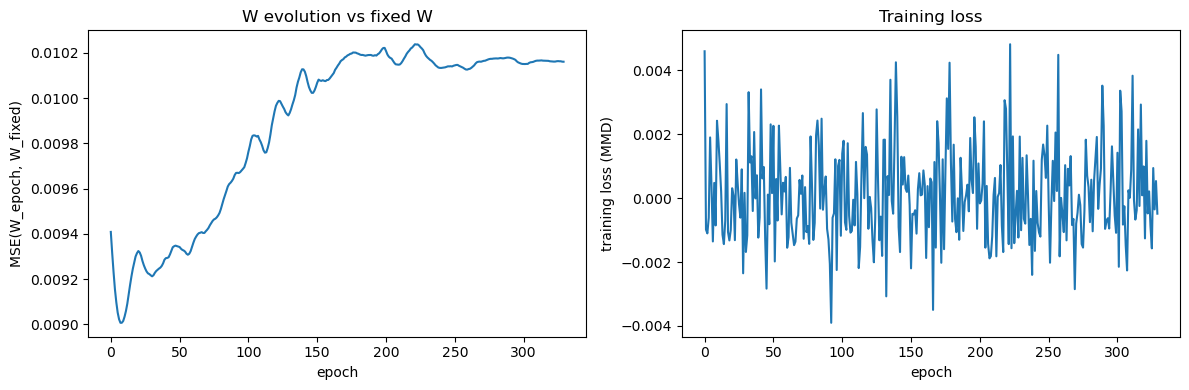

E[W_fixed^2] = 0.009648044446252972
relative MSE  = 1.0531163529984675
||W_fixed||_F = 0.17012975441926353
||W_NN||_F = 0.16789029812506917
||diff||_F    = 0.17458963355701992
Correlation of W_fixed and W_NN = 0.6548956237590996


In [413]:
W_analysis = plot_W_history_vs_fixed(results["run_path"], W_fixed)

In [433]:
# cleaner side-by-side print (you have only 3 columns here)
print("W_NN:", esn.W[:, :5])
print("W_fixed:", W_fixed[:, :5])
print("diff   :", (esn.W - W_fixed)[:, :5])

W_NN: tensor([[ 0.1972, -0.2267,  0.0555]], grad_fn=<SliceBackward0>)
W_fixed: tensor([[-0.0499,  0.1477,  0.0681]], grad_fn=<SliceBackward0>)
diff   : tensor([[ 0.2471, -0.3745, -0.0126]], grad_fn=<SliceBackward0>)


# BFGS trial 

In [434]:
# import torch

# def fit_W_by_lbfgs(
#     *,
#     esn,
#     X_target: torch.Tensor,      # (B,T,d)
#     kernel,
#     kernel_mode: str,            # "static" or "sequential"
#     lead_lag: bool = False,
#     lags: int = 1,
#     xi: torch.Tensor | None = None,     # (B,T,m) fixed drive; if None, ESN samples its own
#     t_tilt: torch.Tensor | None = None, # optional
#     max_iter: int = 200,
#     history_size: int = 20,
#     lr: float = 1.0,
#     tol_grad: float = 1e-10,
#     tol_change: float = 1e-12,
#     verbose: bool = True,
# ):
#     """
#     Fits W to minimize MMD(X_target, Z(W)) with L-BFGS.
#     Assumes ESN state evolution does not depend on W (true in your ESNGenerator).
#     For cleanest behavior set esn.eta_scale = 0 and pass eta=0 (we do).
#     """
#     device = esn.A.device
#     dtype = esn.A.dtype
#     X_target = X_target.to(device=device, dtype=dtype)

#     B, T, d = X_target.shape
#     if d != esn.d:
#         raise ValueError(f"X_target last dim d={d} must match esn.d={esn.d}")

#     # Fix eta to zero so the objective is deterministic in W
#     eta0 = torch.zeros(B, T, esn.d, device=device, dtype=dtype)

#     # Precompute reservoir states once
#     esn.eval()
#     with torch.no_grad():
#         Z0, Xhist = esn(T=T, N=B, xi=xi, eta=eta0, return_states=True)  # Xhist: (B,T,h)

#     # Make W trainable
#     W = torch.nn.Parameter(esn.W.detach().clone())
#     opt = torch.optim.LBFGS(
#         [W],
#         lr=lr,
#         max_iter=max_iter,
#         history_size=history_size,
#         line_search_fn="strong_wolfe",
#         tolerance_grad=tol_grad,
#         tolerance_change=tol_change,
#     )

#     def mmd_from_W():
#         Z = Xhist @ W.T  # (B,T,d)
#         if t_tilt is not None:
#             Z = Z + t_tilt.to(device=device, dtype=dtype)

#         if kernel_mode == "static":
#             Xk = X_target.reshape(B, -1)
#             Zk = Z.reshape(B, -1)
#         else:
#             Xk, Zk = X_target, Z

#         return compute_mmd_loss(kernel, Xk, Zk, lead_lag, lags)

#     loss_trace = []

#     def closure():
#         opt.zero_grad(set_to_none=True)
#         loss = mmd_from_W()
#         loss.backward()
#         return loss

#     # Run LBFGS (it will call closure multiple times)
#     loss0 = float(mmd_from_W().detach().cpu())
#     if verbose:
#         print("Initial MMD:", loss0)

#     opt.step(closure)

#     loss1 = float(mmd_from_W().detach().cpu())
#     if verbose:
#         print("Final MMD:", loss1)

#     # Write back into ESN if you want
#     with torch.no_grad():
#         esn.W.copy_(W)

#     return {"W": W.detach().cpu(), "mmd_initial": loss0, "mmd_final": loss1}

In [435]:
# # 1) Generate a fixed target batch
# B = 128
# T = 200
# noise = Noise("normal")

# with torch.no_grad():
#     X = target_generator.generate(N=B, T=T, noise=noise).to(dtype=esn.A.dtype, device=esn.A.device)

# # 2) Fit W by LBFGS
# lbfgs_results = fit_W_by_lbfgs(
#     esn=esn,
#     X_target=X,
#     kernel=kernel,
#     kernel_mode=kernel_mode,
#     lead_lag=False,
#     lags=0,
#     xi=None,         # let ESN sample; for a stricter test, pass a fixed xi tensor
#     max_iter=200,
#     lr=1.0,
# )

In [436]:
# W_lbfgs = lbfgs_results["W"]  # returned by fit_W_by_lbfgs

# Wf = W_fixed.detach().cpu()
# Wb = W_lbfgs.detach().cpu()

# mse = ((Wb - Wf)**2).mean().item()
# mse0 = (Wf**2).mean().item()
# print("E[W_fixed^2] =", mse0)
# print("relative MSE  =", mse / (mse0 + 1e-12))
# print("||W_fixed||_F =", torch.linalg.norm(Wf).item())
# print("||W_lbfgs||_F =", torch.linalg.norm(Wb).item())
# print("||diff||_F    =", torch.linalg.norm(Wb - Wf).item())

In [451]:
import torch

@torch.no_grad()
def make_common_noise(esn, N, T, *, dtype=torch.float64):
    device = esn.A.device
    xi = torch.randn(N, T, esn.m, device=device, dtype=dtype) * float(esn.xi_scale)
    eta0 = torch.zeros(N, T, esn.d, device=device, dtype=dtype)
    return xi, eta0

def fit_W_mmd_lbfgs_common_noise(
    *,
    esn_model,
    esn_target,
    kernel,
    kernel_mode: str,   # "static" or "sequential"
    N_target: int,
    N_esn: int,
    T: int,
    lead_lag: bool = False,
    lags: int = 1,
    max_iter: int = 1000,
):
    device = esn_model.A.device
    dtype = torch.float64  # force double for sigkernel

    esn_model = esn_model.to(device=device, dtype=dtype).eval()
    esn_target = esn_target.to(device=device, dtype=dtype).eval()

    N_max = max(N_target, N_esn)
    N_min = min(N_target, N_esn)

    # common noise, zero output noise
    xi, eta0 = make_common_noise(esn_model, N_max, T, dtype=dtype)

    with torch.no_grad():
        Zt, _ = esn_target(T=T, N=N_target, xi=xi[:N_min], eta=eta0[:N_min], return_states=True)
        _, Xm = esn_model(T=T, N=N_esn, xi=xi, eta=eta0, return_states=True)
        # Zt, _ = esn_target(T=T, N=N_target, return_states=True)
        # _, Xm = esn_model(T=T, N=N_esn, return_states=True)

        Zt = Zt.to(dtype=dtype)
        Xm = Xm.to(dtype=dtype)

    W = torch.nn.Parameter(esn_model.W.detach().clone().to(dtype=dtype))
    opt = torch.optim.LBFGS([W], lr=1.0, max_iter=max_iter, line_search_fn="strong_wolfe")

    def loss_from_W():
        Zm = Xm @ W.T  # (N,T,d), float64

        if kernel_mode == "static":
            Xk = Zt.reshape(N_target, -1)
            Yk = Zm.reshape(N_esn, -1)
        else:
            Xk, Yk = Zt, Zm

        return compute_mmd_loss(kernel, Xk, Yk, lead_lag, lags)

    def closure():
        opt.zero_grad(set_to_none=True)
        loss = loss_from_W()
        loss.backward()
        return loss

    m0 = float(loss_from_W().detach().cpu())
    opt.step(closure)
    m1 = float(loss_from_W().detach().cpu())

    with torch.no_grad():
        esn_model.W.copy_(W)

    return {"mmd_initial": m0, "mmd_final": m1, "W_fit": W.detach().cpu()}

In [452]:
# import torch

# @torch.no_grad()
# def make_common_noise(esn, N, T, *, dtype=torch.float64):
#     device = esn.A.device
#     xi = torch.randn(N, T, esn.m, device=device, dtype=dtype) * float(esn.xi_scale)
#     eta0 = torch.zeros(N, T, esn.d, device=device, dtype=dtype)
#     return xi, eta0

# def fit_W_mmd_lbfgs_common_noise(
#     *,
#     esn_model,
#     esn_target,
#     kernel,
#     kernel_mode: str,   # "static" or "sequential"
#     N: int,
#     T: int,
#     lead_lag: bool = False,
#     lags: int = 1,
#     max_iter: int = 200,
# ):
#     device = esn_model.A.device
#     dtype = torch.float64  # force double for sigkernel

#     esn_model = esn_model.to(device=device, dtype=dtype).eval()
#     esn_target = esn_target.to(device=device, dtype=dtype).eval()

#     # common noise, zero output noise
#     xi, eta0 = make_common_noise(esn_model, N, T, dtype=dtype)

#     with torch.no_grad():
#         Zt, _ = esn_target(T=T, N=N, xi=xi, eta=eta0, return_states=True)
#         _, Xm = esn_model(T=T, N=N, xi=xi, eta=eta0, return_states=True)

#         Zt = Zt.to(dtype=dtype)
#         Xm = Xm.to(dtype=dtype)

#     W = torch.nn.Parameter(esn_model.W.detach().clone().to(dtype=dtype))
#     opt = torch.optim.LBFGS([W], lr=1.0, max_iter=max_iter, line_search_fn="strong_wolfe")

#     def loss_from_W():
#         Zm = Xm @ W.T  # (N,T,d), float64

#         if kernel_mode == "static":
#             Xk = Zt.reshape(N, -1)
#             Yk = Zm.reshape(N, -1)
#         else:
#             Xk, Yk = Zt, Zm

#         return compute_mmd_loss(kernel, Xk, Yk, lead_lag, lags)

#     def closure():
#         opt.zero_grad(set_to_none=True)
#         loss = loss_from_W()
#         loss.backward()
#         return loss

#     m0 = float(loss_from_W().detach().cpu())
#     opt.step(closure)
#     m1 = float(loss_from_W().detach().cpu())

#     with torch.no_grad():
#         esn_model.W.copy_(W)

#     return {"mmd_initial": m0, "mmd_final": m1, "W_fit": W.detach().cpu()}

In [453]:
torch.set_default_dtype(torch.float64)
# esn.eta_scale = 0.0
# target_esn.eta_scale = 0.0
out = fit_W_mmd_lbfgs_common_noise(
    esn_model=esn,
    esn_target=target_esn,
    kernel=kernel,
    kernel_mode=kernel_mode,
    N_target=100,
    N_esn=100,
    T=50,
)

W_lbfgs = out["W_fit"]
# compare_W_lbfgs_to_fixed(W_lbfgs=W_lbfgs, W_fixed=W_fixed)

In [458]:
Wf = W_fixed.detach().cpu()
Wb = W_lbfgs.detach().cpu()

mse = ((Wb - Wf)**2).mean().item()
mse0 = (Wf**2).mean().item()
print("E[W_fixed^2] =", mse0)
print("relative MSE  =", mse / (mse0 + 1e-12))
print("||W_fixed||_F =", torch.linalg.norm(Wf).item())
print("||W_lbfgs||_F =", torch.linalg.norm(Wb).item())
print("||diff||_F    =", torch.linalg.norm(Wb - Wf).item())
corr = torch.corrcoef(torch.cat([Wb.flatten(), Wf.flatten()])).item()
print("Correlation between W_lbfgs and W_fixed:", corr)

E[W_fixed^2] = 0.009648044446252972
relative MSE  = 9.4670591189222e-05
||W_fixed||_F = 0.17012975441926353
||W_lbfgs||_F = 0.17177741821447767
||diff||_F    = 0.001655342325600354
Correlation between W_lbfgs and W_fixed: 1.0


In [455]:
# cleaner side-by-side print (you have only 3 columns here)
print("W_lbfgs:", Wb[:, :5])
print("W_fixed:", Wf[:, :5])
print("diff   :", abs(Wb - Wf)[:, :5])

W_lbfgs: tensor([[-0.0502,  0.1492,  0.0687]])
W_fixed: tensor([[-0.0499,  0.1477,  0.0681]])
diff   : tensor([[0.0004, 0.0015, 0.0006]])


In [456]:

from models.trainer_ESM_MMD_LBFGS import fit_W_by_lbfgs_mmd


print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")
out = fit_W_by_lbfgs_mmd(
    esn=esn,
    Z_target=X,
    kernel=kernel,
    kernel_mode=kernel_mode,   # "static" or "sequential"
    N_model=2000,           # how many ESN paths to sample for MMD
    lead_lag=False,
    lags=0,
    max_iter=1000,
    lr=1.0,
    force_float64=True,
    verbose=True,
)

W_fit = out["W_fit"]

Using kernel: RBFKernel with kernel mode: static
MMD initial: 0.0006807938338347919
MMD final: 0.00044981953212341885


E[W_fixed^2]          = 0.00964804
MSE(W_fit, W_fixed)   = 0.0691782
relative MSE          = 7.17018
||W_fixed||_F         = 0.17013
||W_fit||_F           = 0.414996
||W_fit-W_fixed||_F   = 0.45556
relative Frobenius    = 2.67772
Corr(flattened)       = -0.732746
W_fit[:5]             = [ 0.26359277 -0.07611829  0.31136276]
W_fixed[:5]           = [-0.0498608   0.14771886  0.06809678]


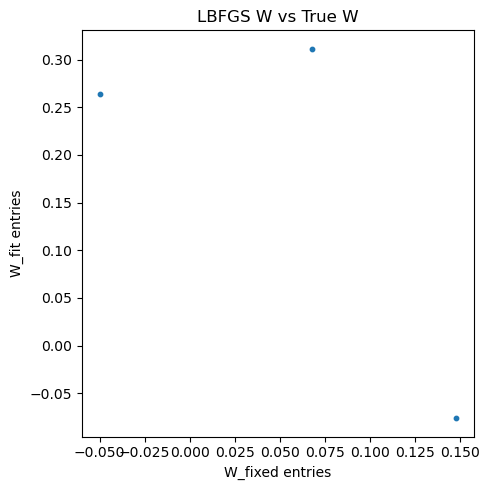

In [457]:

from models.trainer_ESM_MMD_LBFGS import compare_Ws


stats = compare_Ws(
    W_fit=W_fit,
    W_fixed=W_fixed,
    title="LBFGS W vs True W",
    scatter=True,
)